### This notebook is used to compute feature importances: fitting 5 times a BoostedRegressionTree model using different train_test_split

input files: 

    * optimized_model_parms_for_importance_calculation.csv (containing optimized model parameters)
    * median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv (containing dataset features and targets)

output files:

    * feature importance plots (SHAP values, permutation_importances)
    * tables containing ranks of feature importances

settings: 

    * target var must be set: n_imbal, c_imbal, p_imbal, median_DIN, median_SRP or median_DOC_TOC_bioav
    * model type must be defined: either gbr (GradientBoostingRegressor) or lightgbm (LightGBMRegressor)

Load modules:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from numpy import mean
from numpy import std
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
import time
import os
import ast

### Set target_var and model type: 

In [215]:
# select target_var: n_imbal, c_imbal, p_imbal, median_DIN, median_SRP or median_DOC_TOC_bioav
target_var = 'median_DOC_TOC_bioav'

#select model type: 'gbr' or 'lightgbm'
model_type = 'gbr'


Import dataset:

In [216]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

Import optimized parameter sets:

In [ ]:
optimized_parameter_sets = pd.read_csv('../../../output_data/ML_analysis/hyperparameter_settings/optimized_model_parms_for_importance_calculation.csv', sep = ';', dtype={'parameters': str})

# Convert the 'parameters' column to dictionaries

optimized_parameter_sets['parameters'] = optimized_parameter_sets['parameters'].apply(ast.literal_eval)

In [218]:
optimized_parameter_sets

,model,target,parameters,transformation
0,gbr,c_imbal,"{'learning_rate': 0.0018911001294483038, 'max_...",box-cox
1,gbr,n_imbal,"{'learning_rate': 0.001524207186070734, 'max_d...",box-cox
2,gbr,p_imbal,"{'learning_rate': 0.0018696900876637153, 'max_...",box-cox
3,gbr,median_DOC_TOC_bioav,"{'learning_rate': 0.0019202958248987234, 'max_...",box-cox
4,gbr,median_DIN,"{'learning_rate': 0.00420545212113823, 'max_de...",box-cox
5,gbr,median_SRP,"{'learning_rate': 0.0014628853574732998, 'max_...",box-cox
6,lightgbm,c_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
7,lightgbm,n_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
8,lightgbm,p_imbal,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox
9,lightgbm,median_DIN,"{'colsample_bytree': 0.4, 'learning_rate': 0.0...",box-cox


## Prepare the data for the machine learning models:

1. Split data into features and targets
2. Convert data frame to arrays 
3. Split data into training and test set

1. Function to prepare input data: split data into target and features and convert to arrays: 

In [219]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,0:43]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    #features = np.array(features)

    return target, features, feature_list

### Apply create_input_ML function:

In [220]:
# data:
data = nutrient_export_data

In [221]:
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

### Define a folder to save the results:

In [222]:
# Define the directory path
dir_path = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}"

# Check if the directory exists, create it if it doesn't
if not os.path.exists(dir_path):
    os.makedirs(dir_path)


### Fit Boosting regression tree using best  parameters 5 times:

In [223]:
# extract best parameters: squeeze() funtion is required, to convert Series object to one value (result of loc operation is always a pandas series, even if output is only one value):
best_parms =  optimized_parameter_sets.loc[(optimized_parameter_sets['target'] == target_var) & (optimized_parameter_sets['model'] == model_type), 'parameters'].squeeze()

In [224]:
best_parms

{'learning_rate': 0.0019202958248987234,
 'max_depth': 9,
 'max_features': 4,
 'n_estimators': 7275,
 'subsample': 0.5}

Set random state values: for 5 different iterations:

In [225]:

#set random_state:
run_number = [1,2,3,4,5]
random_state_split = [2, 19, 44, 33, 21]
random_state_regressor = [4, 9, 19, 31, 41]
random_state_feature_importances = [1, 17, 45, 22, 12]

In [226]:
### Now calculate for all 5 splits feature importances, permutation feature importances and SHAP values:

R2 Train: 0.8762525632030529
R2 Test: 0.729097210129723


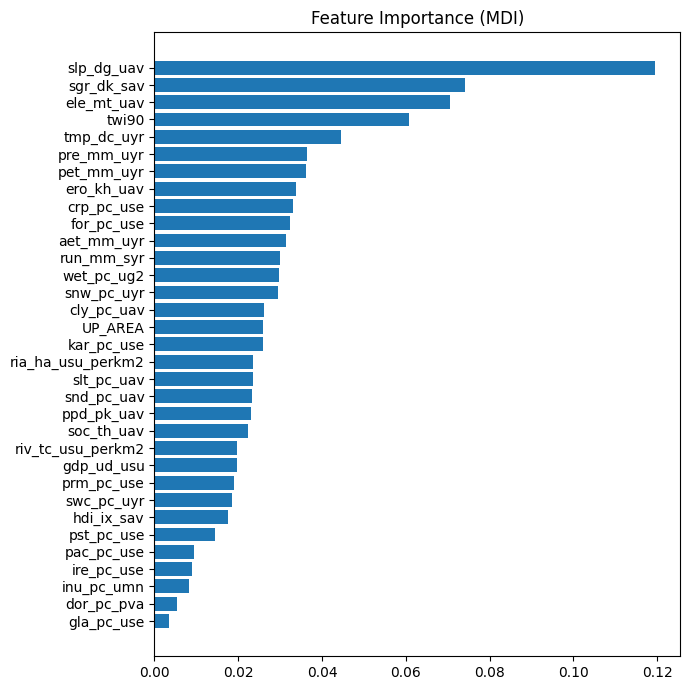

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\506180388.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


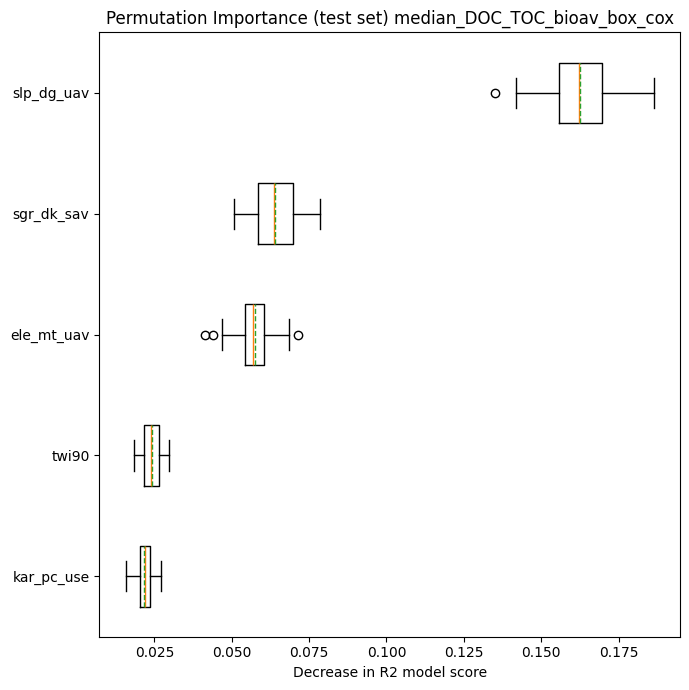

R2 Train: 0.8713461251024985
R2 Test: 0.6771131488782128


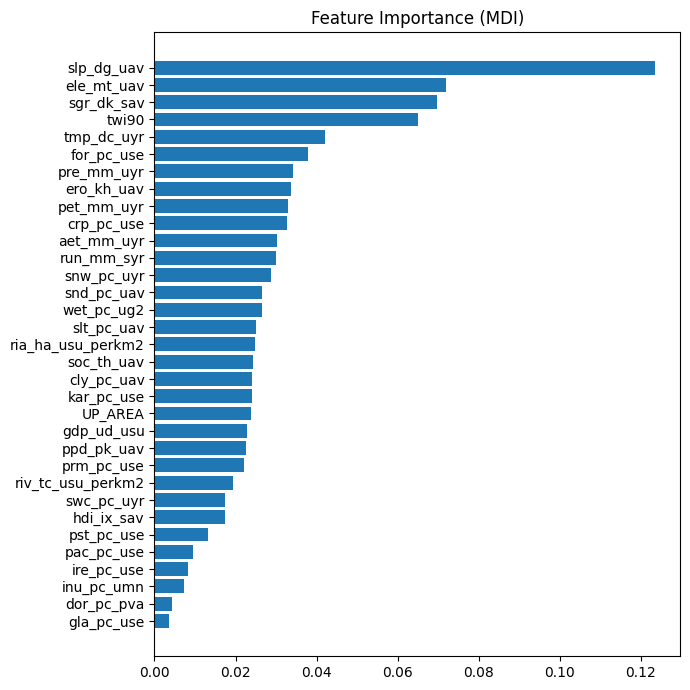

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\506180388.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


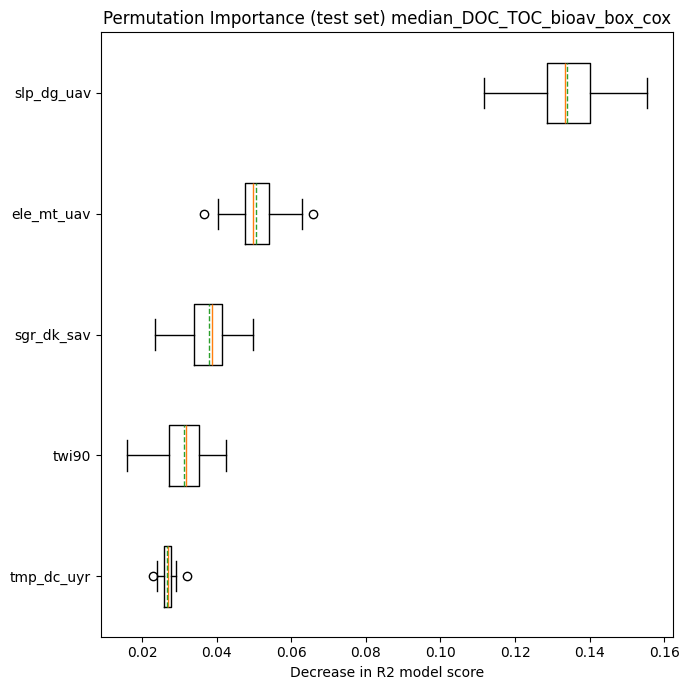

R2 Train: 0.8945639952931275
R2 Test: 0.7083502538505739


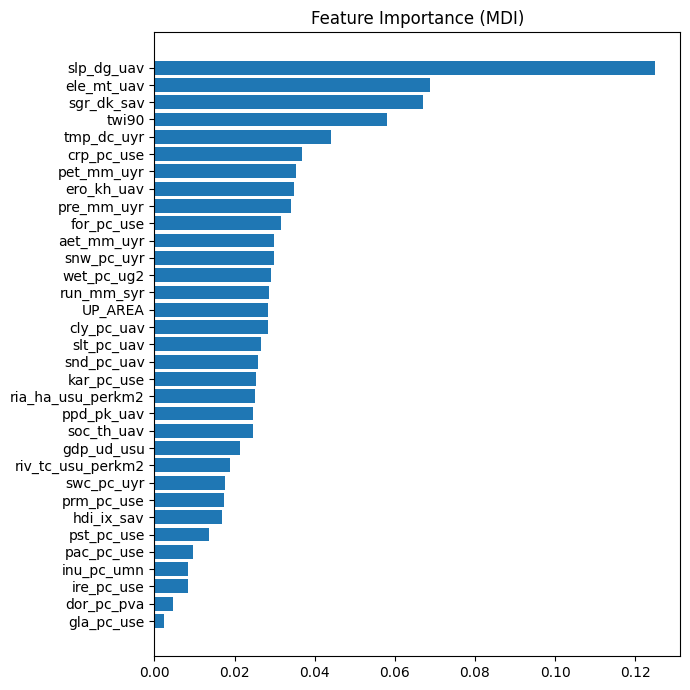

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\506180388.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


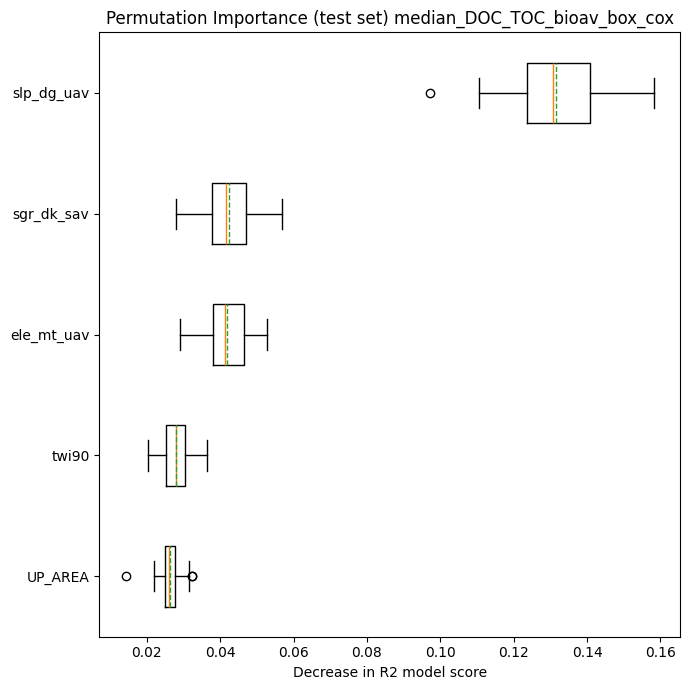

R2 Train: 0.8846404023680579
R2 Test: 0.6710717278314788


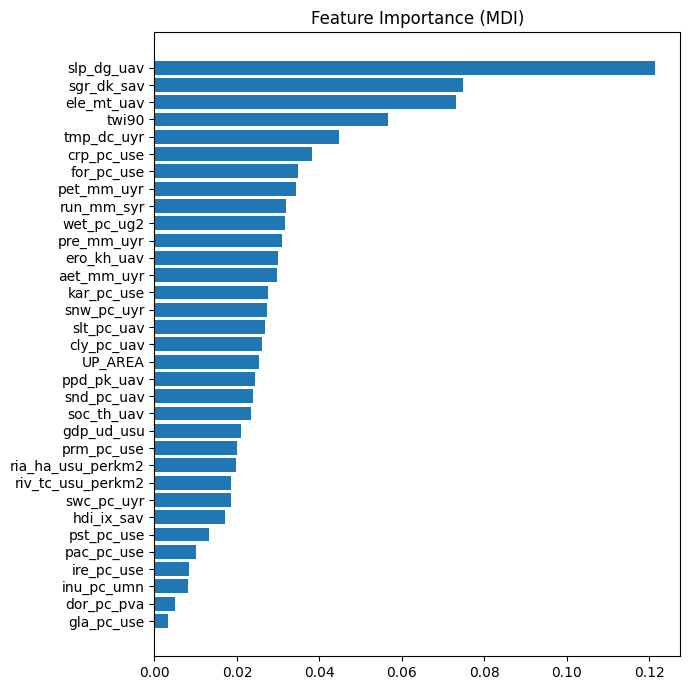

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\506180388.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


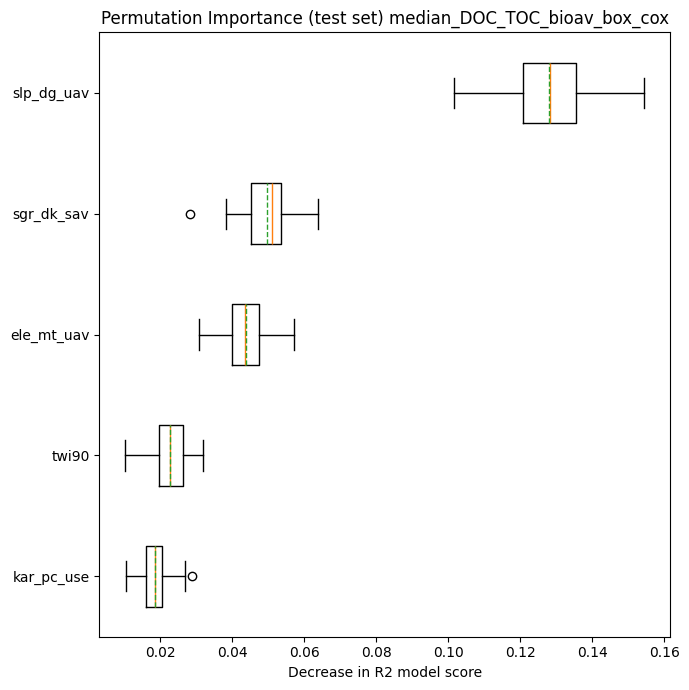

R2 Train: 0.8728039533335872
R2 Test: 0.7307761083676665


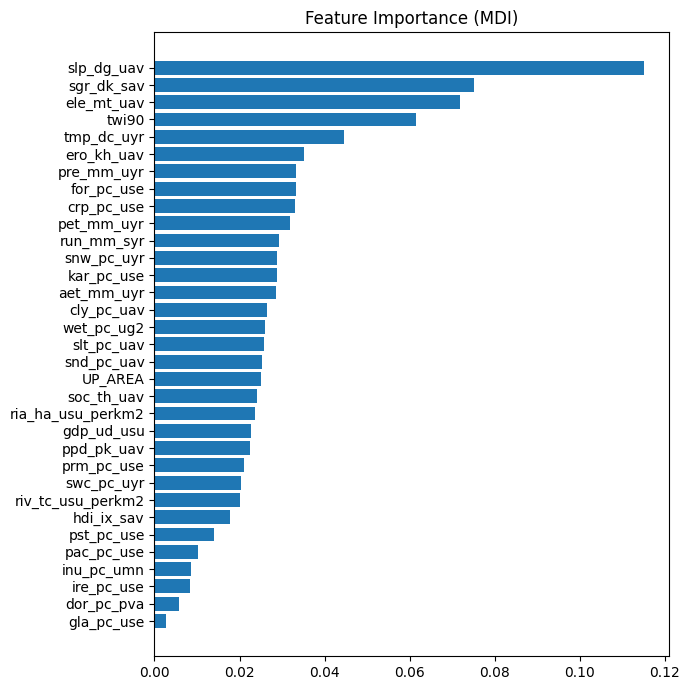

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\506180388.py:168: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


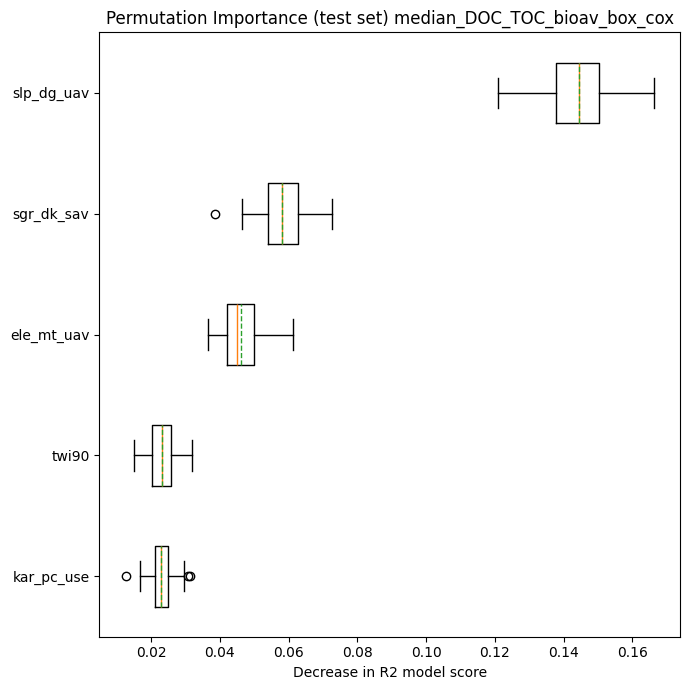

In [227]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import os


# create empty data lists to save data:

# feature importances:
feat_importance_results = []

# permutation importances:
perm_imp_results = []



# test_features_runs 

test_features_splits = []

r2_train_splits = []
r2_test_splits = []

models_splits = []



 # Specify the directory name
dir_permutation = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}/perm_importance"
dir_importance = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}/MDI_importance"




# loop to split the data into training and test data and to fit the model: using diffent random states:
for i, (split, regressor, feature) in enumerate(zip(random_state_split, random_state_regressor, random_state_feature_importances)):
    train_features, test_features, train_targets, test_targets = train_test_split(features, target, test_size=0.20, random_state=split)

    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='box-cox')

    # Reshape train_targets to 2D if it's 1D
    if len(train_targets.shape) == 1:
        train_targets2 = np.reshape(train_targets, (-1, 1))

    # Fit the transformer to the training data
    # This learns the best lambda value for each feature
    pt.fit(train_targets2)

    # Transform the training data using the learned lambda values
    train_targets_transformed_bc = pt.transform(train_targets2)
    # convert back to 1D format
    train_targets_transformed_bc = train_targets_transformed_bc.ravel()

    # Transform the test data using the same lambda values
    # Reshape test_targets to 2D if it's 1D
    if len(test_targets.shape) == 1:
        test_targets2 = np.reshape(test_targets, (-1, 1))

    test_targets_transformed_bc = pt.transform(test_targets2)
    test_targets_transformed_bc = test_targets_transformed_bc.ravel()


    # save test_features to list:
    test_features_splits.append(test_features)
    
    # fit the model:
    if model_type == 'lightgbm':
        # Create a new dictionary with all the parameters
        params = best_parms.copy()  # Start with a copy of best_params
        params.update({
            "subsample_for_bin":200000, 
            "objective":None, 
            "class_weight":None, 
            "min_split_gain":0.0, 
            "min_child_weight":0.001, 
            "subsample_freq":0, 
            "reg_alpha":0.0, 
            "reg_lambda":0.0, 
            "random_state":5, 
            "importance_type":'split', 
            "n_jobs": 10,})
        
        # split training set again, to get an validation fraction for the early stopping:
        train_features2, eval_features, train_targets_transformed_bc2, eval_targets_transformed_bc = train_test_split(train_features, train_targets_transformed_bc, test_size=0.10, random_state=split)
        model = lgb.LGBMRegressor(boosting_type='gbdt',metric='rmse', **best_parms, verbose = -1, early_stopping_rounds= 10)
        # Fit the model:
        model.fit(train_features2, train_targets_transformed_bc2, 
                 eval_set=[(eval_features, eval_targets_transformed_bc)],
                 #eval_metric='rmse',  
                 )
        #train_features = train_features2.copy()
        #train_targets_transformed_bc =train_targets_transformed_bc2.copy()
        

    else: 
        model = GradientBoostingRegressor(**best_parms,  random_state = regressor, validation_fraction = 0.1, n_iter_no_change = 10)


        # Fit the model:
        model.fit(train_features, train_targets_transformed_bc)

    # save the model to a list:
    models_splits.append(model)

    
    # make predictions on train- and test-features:
    pred_train = model.predict(train_features)
    pred_test = model.predict(test_features)

    r2_train = r2_score(train_targets_transformed_bc, pred_train)
    r2_test = r2_score(test_targets_transformed_bc, pred_test)
    print(f"R2 Train: {r2_train}")
    print(f"R2 Test: {r2_test}")
    r2_train_splits.append(r2_train)
    r2_test_splits.append(r2_test)


    
    plt.figure(figsize=(7, 7))
    
    # calculate default feature importance:
    feature_importance = model.feature_importances_
    # append results to list feat_importance_results:
    feat_importance_results.append(feature_importance)
    
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    
    #plt.subplot(2, 2, 1)
    plt.barh(pos, feature_importance[sorted_idx], align="center")
    plt.yticks(pos, np.array(feature_list)[sorted_idx])
    if model_type == 'lightgbm':
        plt.title("Feature Importance (Split Count)")

    if model_type == 'gbr':
        plt.title("Feature Importance (MDI)")
    # Adjust the layout
    plt.tight_layout()

    
   
    # Check if the directory exists
    if not os.path.exists(dir_importance):
        # If the directory does not exist, create it
        os.makedirs(dir_importance)
    plt.savefig(f"{dir_importance}/mdi_feat_imp_{target_var}_split{i}_bc.png")
    plt.show()
    
    # calculate permutation importance using 70 repeats: random state is set to feature
    # scoring R2 and 
    scoring_permutation_imp ={'R2': 'r2',
           'explained_var': 'explained_variance'}
    result = permutation_importance(
        model, test_features, test_targets_transformed_bc, n_repeats=70, random_state= feature, n_jobs=10, scoring = scoring_permutation_imp
    )

    # append result to list perm_imp_results:
    perm_imp_results.append(result['R2'])
    
    sorted_idx2 = result['R2'].importances_mean.argsort()
    
    fig1 = plt.figure(figsize=(7, 7))
    plt.boxplot(
        result['R2'].importances[sorted_idx2][-5:].T,
        vert=False,
        labels=np.array(feature_list)[sorted_idx2][-5:],
        meanline=True,
        showmeans=True)
    plt.title(f"Permutation Importance (test set) {target_var}_box_cox")
    plt.xlabel("Decrease in R2 model score")
    # Adjust the layout
    plt.tight_layout()


   
    # Check if the directory exists
    if not os.path.exists(dir_permutation):
        # If the directory does not exist, create it
        os.makedirs(dir_permutation)
    
    plt.savefig(f"{dir_permutation}/perm_feat5_{target_var}_split{i}_bc.png")
    plt.show()


    
    

In [228]:
import pickle
with open(f"{dir_path}/{target_var}_perm_imp_results_dataframes_5splits.pkl", 'wb') as f:
    pickle.dump(perm_imp_results, f)

###  If files from cell above already exist, this is much faster than fitting the models again:

In [229]:
perm_imp_results

[{'importances_mean': array([4.73368426e-03, 2.41731560e-02, 1.62365565e-01, 1.18746008e-02,
         1.62241674e-02, 2.99383771e-03, 5.05760414e-03, 1.59318172e-02,
         2.03705828e-05, 7.60440921e-04, 8.95020371e-03, 1.79428311e-03,
         5.73768661e-02, 6.39057767e-02, 1.71201333e-02, 1.66513970e-02,
         1.60220305e-02, 1.00579143e-02, 1.12833782e-02, 1.98419980e-02,
         1.94571953e-03, 4.29722383e-04, 3.47087335e-03, 2.12486904e-03,
         1.20040986e-02, 1.44324943e-02, 1.52777852e-02, 8.39856701e-03,
         5.49070885e-03, 2.17971888e-02, 1.50818506e-02, 7.19977229e-03,
         6.18292093e-03]),
  'importances_std': array([0.00133002, 0.00299914, 0.01035978, 0.00160465, 0.0027654 ,
         0.00083759, 0.00145914, 0.00239658, 0.00063538, 0.00056774,
         0.00201666, 0.00094652, 0.0057381 , 0.00699451, 0.0017271 ,
         0.00204919, 0.00179888, 0.0012847 , 0.00219737, 0.00280283,
         0.0008641 , 0.0002562 , 0.00088552, 0.00053798, 0.00116574,
     

### If data already exist you can also load file here:

In [230]:
import pickle
# select target_var: n_imbal, c_imbal, p_imbal, median_DIN, median_SRP or median_DOC_TOC_bioav
#target_var = 'median_SRP'

#select model type: 'gbr' or 'lightgbm'
#model_type = 'gbr'
# Define the directory path
dir_path = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}"

# Check if the directory exists, create it if it doesn't
if not os.path.exists(dir_path):
    os.makedirs(dir_path)

with open(f"{dir_path}/{target_var}_perm_imp_results_dataframes_5splits.pkl", 'rb') as f:
    perm_imp_results = pickle.load(f)

### Finally, calculation of the ranking of permutation feature importances across all 5 models (with different data splits): 5 *70 permutation importance values per feature

1. Calculate mean and std values of permutation values across all 5 models for each feature 
2. Create boxplots showing all permutations importances per feature and ranking of features


In [231]:
# extract importances of all 5 different models:
importance_list = [perm_result.importances for perm_result in perm_imp_results]

# combine importances of all 5 models (70values  * 5) in order to subsequently calculate overall mean values + standard deviations:
combined_importances_5splits = np.concatenate(importance_list, axis = 1)
len(combined_importances_5splits)

33

### calculate standard deviation values of permutation feature importances for all 33 features across 5 models (different data splits)

In [232]:
std_values_importances_5models = np.std(combined_importances_5splits, axis = 1)

### calculate mean values of permutation feature importances for all 33 features across 5 models (different data splits)

In [233]:
mean_values_importances_5models = np.mean(combined_importances_5splits, axis = 1)
mean_values_importances_5models

array([1.09104204e-02, 2.58807324e-02, 1.40077747e-01, 1.13866695e-02,
       1.59928441e-02, 2.97522648e-03, 4.93795187e-03, 1.34455302e-02,
       1.26571250e-03, 1.21949833e-03, 6.64690605e-03, 2.18533604e-03,
       4.79488869e-02, 5.04093620e-02, 1.59195830e-02, 1.61294133e-02,
       9.83724166e-03, 9.47447181e-03, 1.01158268e-02, 1.49140670e-02,
       1.73398803e-03, 2.72322305e-05, 7.74962751e-03, 1.50616218e-03,
       9.35763512e-03, 7.88298770e-03, 1.21803143e-02, 7.22118712e-03,
       3.56171402e-03, 2.10232422e-02, 1.45266635e-02, 6.57005209e-03,
       4.05871657e-03])

### Now plot boxplots: one only for the 5 most important features and one for all features:

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\1203242382.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


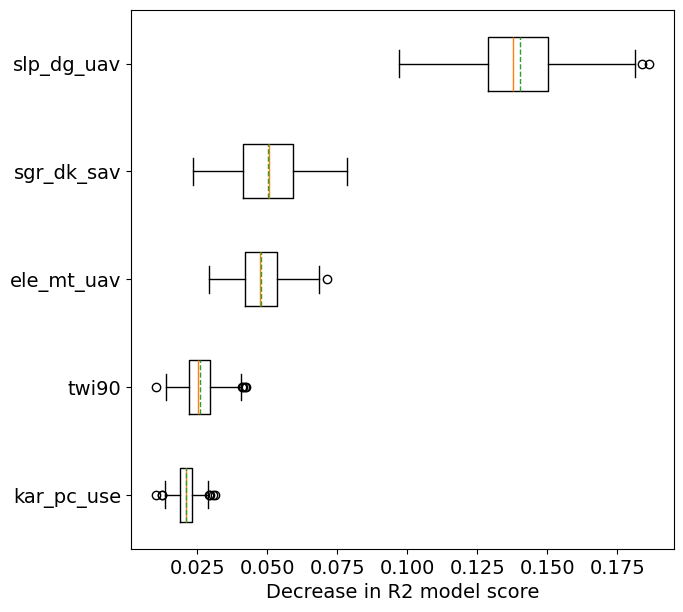

C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\1203242382.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


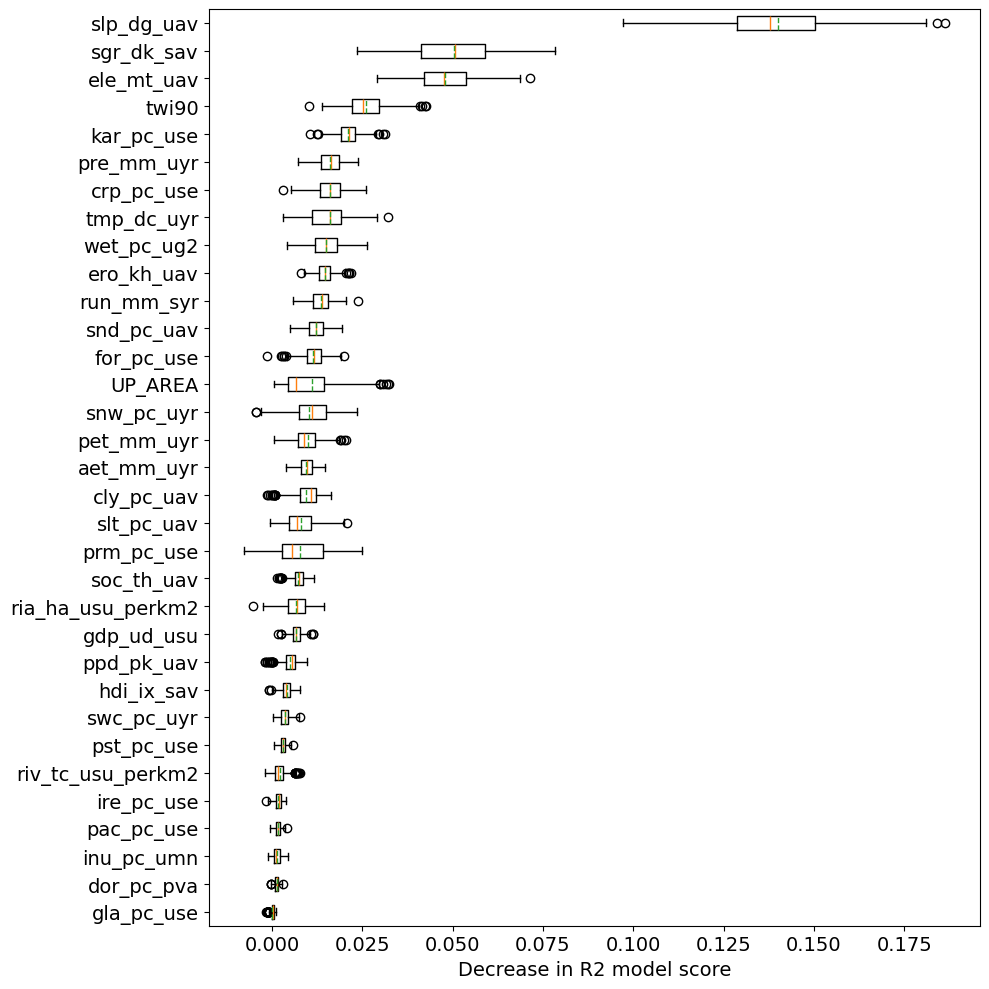

In [238]:
sorted_ids = mean_values_importances_5models.argsort()
    
fig1, ax = plt.subplots(figsize=(7, 7))
plt.boxplot(
        combined_importances_5splits[sorted_ids][-5:].T,
        vert=False,
        labels=np.array(feature_list)[sorted_ids][-5:],
        meanline=True,
        showmeans=True)
ax.tick_params(axis='both', labelsize=14)
#plt.title(f"Permutation Importance (test set) {target_var}_box_cox")
plt.xlabel("Decrease in R2 model score", fontsize = 14)
# Adjust the layout
plt.tight_layout
plt.savefig(f"{dir_path}/perm_importance/{target_var}_bc_mean_5mostimp.png")
plt.show()



fig2, ax = plt.subplots(figsize=(10, 10))
plt.boxplot(
        combined_importances_5splits[sorted_ids].T,
        vert=False,
        labels=np.array(feature_list)[sorted_ids],
        meanline=True,
        showmeans=True)
ax.tick_params(axis='both', labelsize=14)
#plt.title(f"Permutation Importance (test set) {target_var}_box_cox")
plt.xlabel("Decrease in R2 model score", fontsize = 14)
# Adjust the layout
plt.tight_layout()
plt.savefig(f"{dir_path}/perm_importance/{target_var}_bc_mean_ranks_all_feat.png")
plt.show()

In [239]:
print(f"{dir_path}/{target_var}_box_cox_perm_imp_mean_ranks_all_features.png")

../../../output_data/ML_analysis/feature_importances/median_DOC_TOC_bioav_gbr/median_DOC_TOC_bioav_box_cox_perm_imp_mean_ranks_all_features.png


### Save R2 scores of the models with different train_test splits:

In [240]:
# Create a DataFrame with R1 and R2 values
r2_scores_df = pd.DataFrame({
    'Rscore': ['R2_train', 'R2_test'],
    'split1': [r2_train_splits[0], r2_test_splits[0]],
    'split2': [r2_train_splits[1], r2_test_splits[1]],
    'split3': [r2_train_splits[2], r2_test_splits[2]],
    'split4': [r2_train_splits[3], r2_test_splits[3]],
    'split5': [r2_train_splits[4], r2_test_splits[4]],
})
r2_scores_df

,Rscore,split1,split2,split3,split4,split5
0,R2_train,0.876253,0.871346,0.894564,0.884640,0.872804
1,R2_test,0.729097,0.677113,0.708350,0.671072,0.730776


In [241]:
r2_scores_df.to_csv(f"{dir_path}/{target_var}_r2_scores_5splits.csv")

Create a combined plot of all permutation importances:


C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\393817141.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i//3, i%3].boxplot(
C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\393817141.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i//3, i%3].boxplot(
C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\393817141.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i//3, i%3].boxplot(
C:\Users\alexd\AppData\Local\Temp\ipykernel_20844\393817141.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name wil

FileNotFoundError: [Errno 2] No such file or directory: '../../../output_data/ML_analysis/feature_importances/median_DOC_TOC_bioav_gbr/perm_importance/median_DOC_TOC_bioav_box_cox_perm_imp_summary.png'

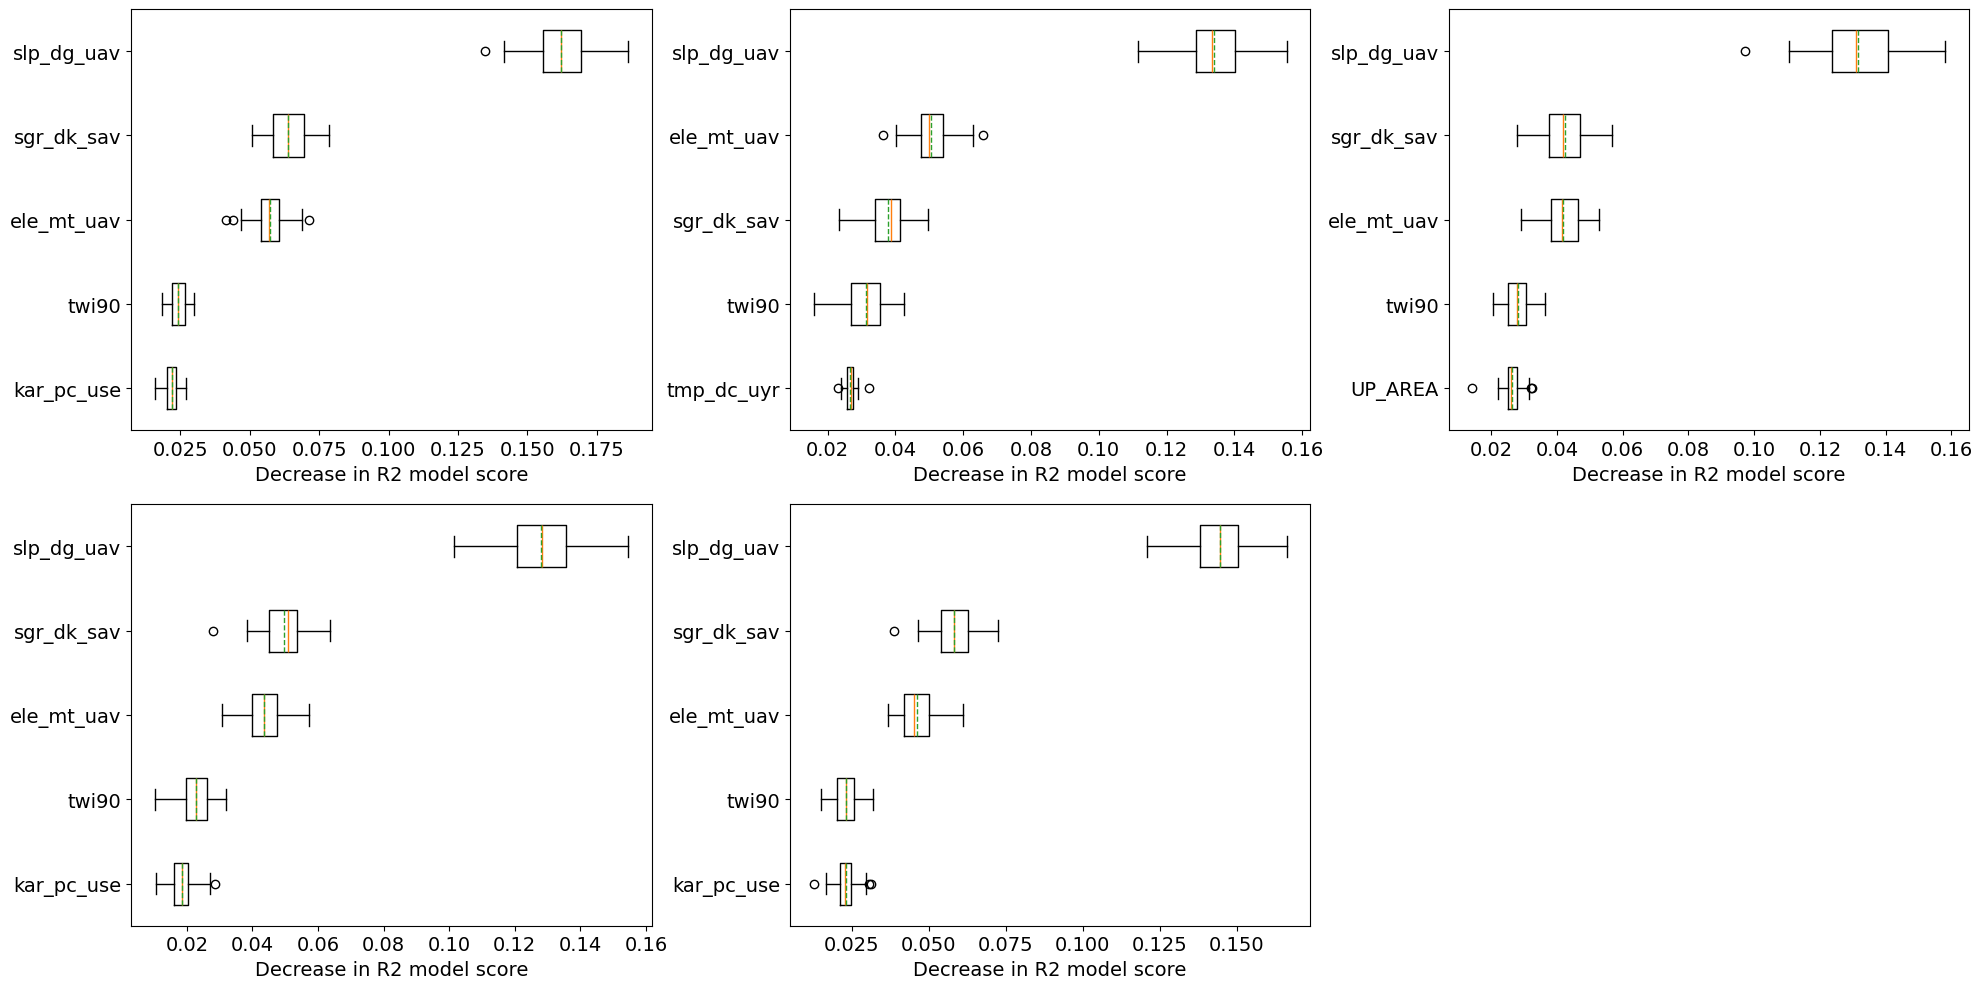

In [242]:
# Create a combined plot with 5 subplots:
fig, axs = plt.subplots(2, 3, figsize = (20, 10))

table_5most_imp = pd.DataFrame({'rank':list(range(1, 6))})
table_most_imp = pd.DataFrame({'rank':list(range(1, 34))})


for i, element in enumerate(perm_imp_results):
    sorted_idx = element.importances_mean.argsort()
    axs[i//3, i%3].boxplot(
        element.importances[sorted_idx][-5:].T,
        vert=False,
        labels=np.array(feature_list)[sorted_idx][-5:],
        meanline=True,
        showmeans=True)
    #axs[i//3, i%3].set_title(f"Permutation Importance (test set) {target_var} (Box_Cox) {i+1}")
    axs[i//3, i%3].set_xlabel("Decrease in R2 model score", fontsize = 14)
    axs[i//3, i%3].tick_params(axis='both', labelsize=14)
    
    # create a table containing 5 most important ranks:
    table_5most_imp[f'run_{i+1}'] = np.array(feature_list)[sorted_idx][-5:][::-1]


    # create a table containing ranks, mean value and std:
    table_most_imp[f'feat_run_{i+1}'] = np.array(feature_list)[sorted_idx][::-1]
    table_most_imp[f'mean_run_{i+1}'] = element.importances_mean[sorted_idx][::-1]
    table_most_imp[f'std_run_{i+1}'] = element.importances_std[sorted_idx][::-1]
    
    
plt.tight_layout()
fig.delaxes(axs.flatten()[5])
plt.savefig(f"{dir_path}/perm_importance/{target_var}_box_cox_perm_imp_summary.png")
plt.show()    


### Append mean ranking of most important features and save list of 5most important features:

In [243]:
sorted_ids = mean_values_importances_5models.argsort()
table_5most_imp['mean_5runs'] = np.array(feature_list)[sorted_ids][-5:][::-1]

In [244]:
table_5most_imp

,rank,run_1,run_2,run_3,run_4,run_5,mean_5runs
0,1,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav
1,2,sgr_dk_sav,ele_mt_uav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav
2,3,ele_mt_uav,sgr_dk_sav,ele_mt_uav,ele_mt_uav,ele_mt_uav,ele_mt_uav
3,4,twi90,twi90,twi90,twi90,twi90,twi90
4,5,kar_pc_use,tmp_dc_uyr,UP_AREA,kar_pc_use,kar_pc_use,kar_pc_use


In [245]:
table_5most_imp.to_csv(f"{dir_path}/{target_var}_5most_perm_imp_5splits.csv")

### Append mean ranking of most important features and save list of ranking most important features including mean and std importance values:

In [246]:
table_most_imp['feat_all_5runs'] = np.array(feature_list)[sorted_ids][::-1]
table_most_imp['mean_all_5runs'] = mean_values_importances_5models[sorted_ids][::-1]
table_most_imp['std_all_5runs'] = std_values_importances_5models[sorted_ids][::-1]

In [247]:
table_most_imp

,rank,feat_run_1,mean_run_1,std_run_1,feat_run_2,mean_run_2,std_run_2,feat_run_3,mean_run_3,std_run_3,feat_run_4,mean_run_4,std_run_4,feat_run_5,mean_run_5,std_run_5,feat_all_5runs,mean_all_5runs,std_all_5runs
0,1,slp_dg_uav,0.162366,0.010360,slp_dg_uav,0.133960,0.008616,slp_dg_uav,0.131461,0.011907,slp_dg_uav,0.128103,0.011173,slp_dg_uav,0.144499,0.008867,slp_dg_uav,0.140078,0.016113
1,2,sgr_dk_sav,0.063906,0.006995,ele_mt_uav,0.050627,0.005386,sgr_dk_sav,0.042362,0.006850,sgr_dk_sav,0.049715,0.006361,sgr_dk_sav,0.058193,0.006678,sgr_dk_sav,0.050409,0.011633
2,3,ele_mt_uav,0.057377,0.005738,sgr_dk_sav,0.037870,0.005521,ele_mt_uav,0.041871,0.005716,ele_mt_uav,0.043670,0.006136,ele_mt_uav,0.046199,0.005769,ele_mt_uav,0.047949,0.007999
3,4,twi90,0.024173,0.002999,twi90,0.031222,0.006038,twi90,0.027991,0.003669,twi90,0.022717,0.004635,twi90,0.023301,0.003886,twi90,0.025881,0.005442
4,5,kar_pc_use,0.021797,0.002421,tmp_dc_uyr,0.026688,0.001457,UP_AREA,0.026404,0.002638,kar_pc_use,0.018394,0.003467,kar_pc_use,0.023036,0.003409,kar_pc_use,0.021023,0.003358
5,6,wet_pc_ug2,0.019842,0.002803,kar_pc_use,0.021372,0.002934,kar_pc_use,0.020518,0.002520,ero_kh_uav,0.013726,0.001995,wet_pc_ug2,0.017393,0.002321,pre_mm_uyr,0.016129,0.003285
6,7,tmp_dc_uyr,0.017120,0.001727,prm_pc_use,0.019516,0.001813,pre_mm_uyr,0.018887,0.002401,run_mm_syr,0.013333,0.003035,ero_kh_uav,0.016771,0.002132,crp_pc_use,0.015993,0.004004
7,8,pre_mm_uyr,0.016651,0.002049,crp_pc_use,0.018400,0.004053,tmp_dc_uyr,0.016949,0.001557,wet_pc_ug2,0.013097,0.003248,crp_pc_use,0.016642,0.003104,tmp_dc_uyr,0.015920,0.006803
8,9,crp_pc_use,0.016224,0.002765,pre_mm_uyr,0.018024,0.002554,crp_pc_use,0.016342,0.004010,for_pc_use,0.012894,0.002547,pre_mm_uyr,0.014460,0.002314,wet_pc_ug2,0.014914,0.004280
9,10,pet_mm_uyr,0.016022,0.001799,snw_pc_uyr,0.017281,0.001841,ero_kh_uav,0.013837,0.002237,pre_mm_uyr,0.012625,0.002359,run_mm_syr,0.013505,0.002701,ero_kh_uav,0.014527,0.002393


In [248]:
table_most_imp.to_csv(f"{dir_path}/{target_var}_summary_perm_imp_5splits.csv")

In [249]:
table_5most_imp

,rank,run_1,run_2,run_3,run_4,run_5,mean_5runs
0,1,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav
1,2,sgr_dk_sav,ele_mt_uav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav
2,3,ele_mt_uav,sgr_dk_sav,ele_mt_uav,ele_mt_uav,ele_mt_uav,ele_mt_uav
3,4,twi90,twi90,twi90,twi90,twi90,twi90
4,5,kar_pc_use,tmp_dc_uyr,UP_AREA,kar_pc_use,kar_pc_use,kar_pc_use


### Define a folder to save partial dependence plots:

In [250]:
# Define the directory path
dir_path_dependence = f"../../../output_data/ML_analysis/feature_importances/{target_var}_{model_type}/partial_dependence_plots"

# Check if the directory exists, create it if it doesn't
if not os.path.exists(dir_path_dependence):
    os.makedirs(dir_path_dependence)


## Get 5 most important features for partial dependence plots:

In [251]:
table_5most_imp

,rank,run_1,run_2,run_3,run_4,run_5,mean_5runs
0,1,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav,slp_dg_uav
1,2,sgr_dk_sav,ele_mt_uav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav,sgr_dk_sav
2,3,ele_mt_uav,sgr_dk_sav,ele_mt_uav,ele_mt_uav,ele_mt_uav,ele_mt_uav
3,4,twi90,twi90,twi90,twi90,twi90,twi90
4,5,kar_pc_use,tmp_dc_uyr,UP_AREA,kar_pc_use,kar_pc_use,kar_pc_use


In [252]:
perm_imp_features = table_5most_imp['mean_5runs']

### Plot partial dependence plots for the five most important features: each for all five different train_test splits:

c:\Users\alexd\cnp_env\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 'slp_dg_uav' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\alexd\cnp_env\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 'sgr_dk_sav' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\alexd\cnp_env\Lib\site-packages\sklearn\inspection\_partial_depen

FileNotFoundError: [Errno 2] No such file or directory: '../../../output_data/ML_analysis/feature_importances/median_DOC_TOC_bioav_gbr/partial_dependence_plots/median_DOC_TOC_bioav_manually_partial_dependence.png'

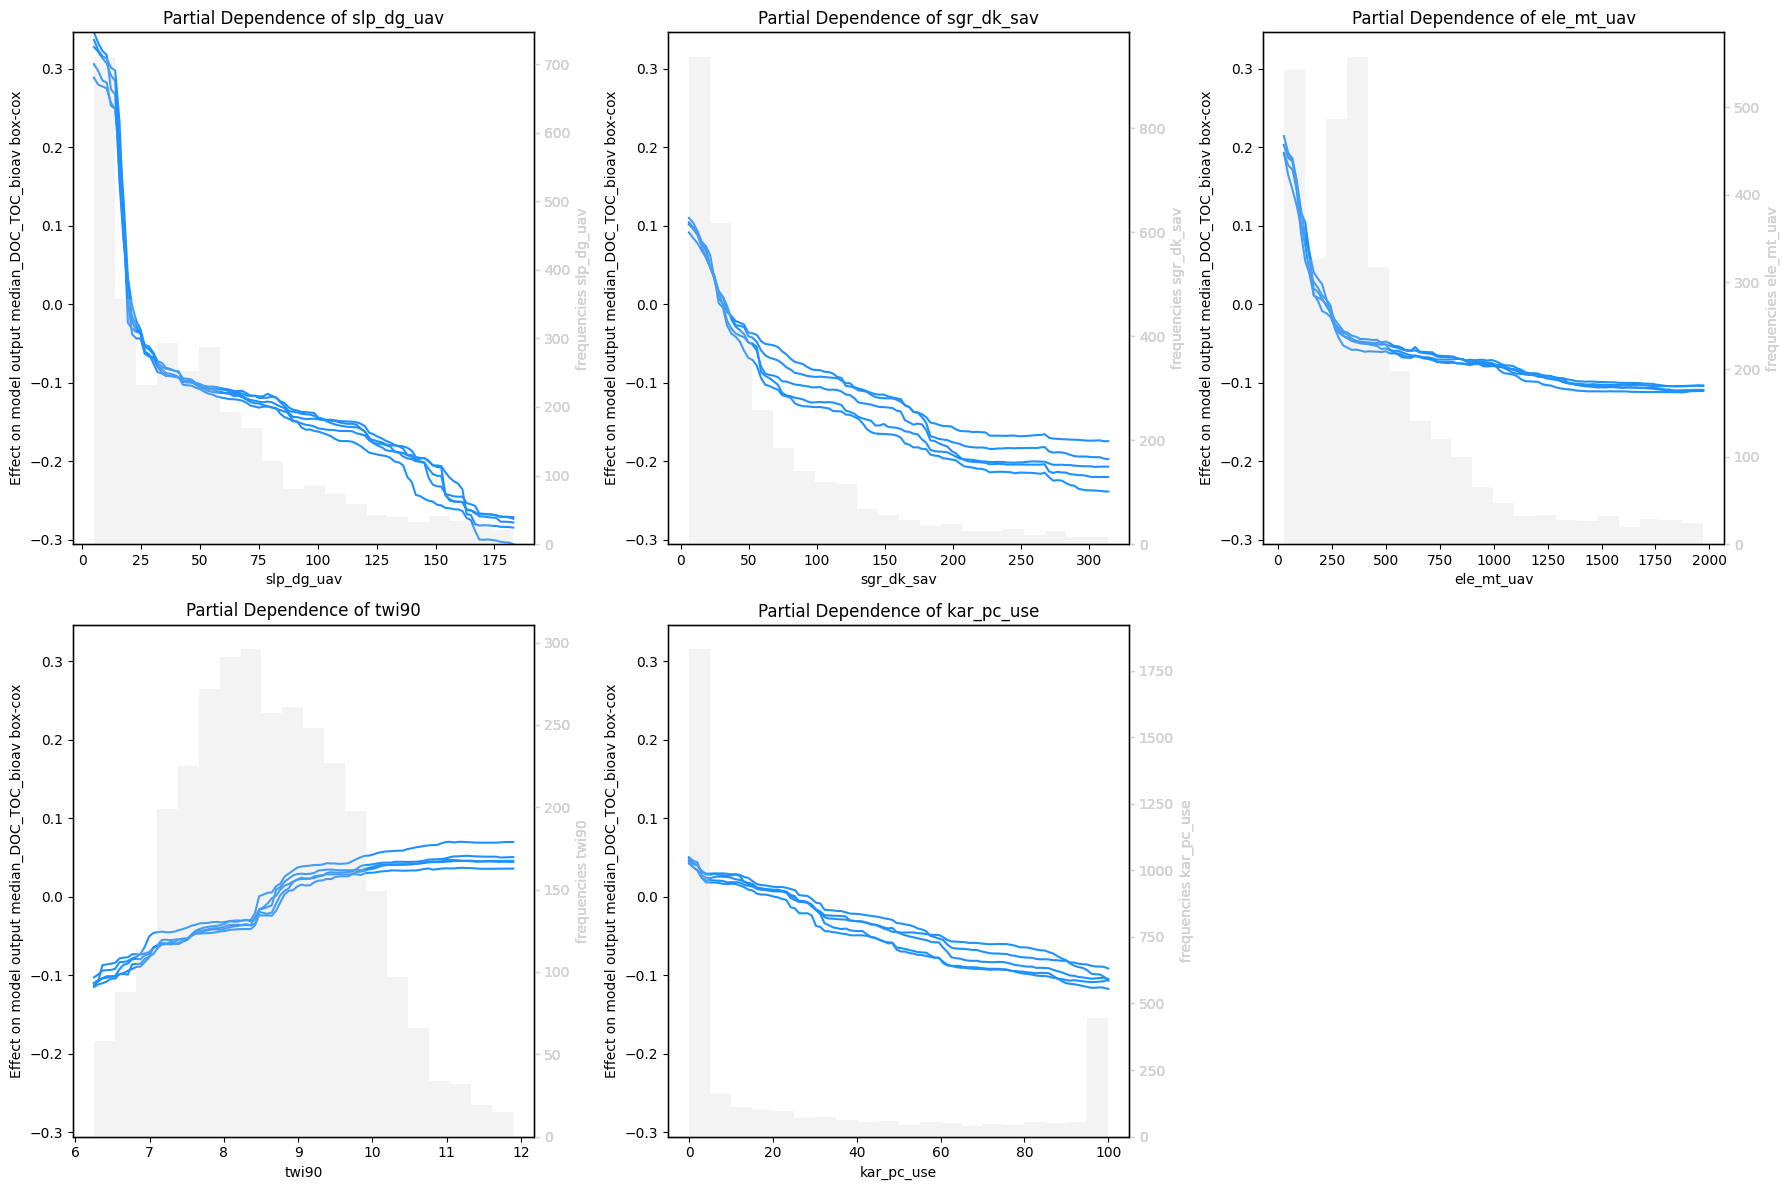

In [ ]:
from sklearn.inspection import partial_dependence

# calculate Partial dependence data manually and plot them:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns:

y_max = -float(0)
y_min = float(0)

for n, test_features_i in enumerate(test_features_splits):
    
    pdp_results_splits = []

    for i, feature in enumerate(perm_imp_features):
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        pdp_results = partial_dependence(models_splits[n],features, [feature], method = 'brute', percentiles = (0.05, 0.95), grid_resolution = 100) # method = 'brute' is recommended for GraidentBoostingRegression models
        pdp_results_splits.append(pdp_results)
        ax.plot(pdp_results['grid_values'][0], pdp_results['average'][0], color = 'dodgerblue')
        ax.set_title(f'Partial Dependence of {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel(f'Effect on model output {target_var} box-cox')
   
        
        # set axis limits:
        y_max_value = pdp_results.average.max() 
        if y_max_value > y_max:
            y_max = y_max_value

        y_min_value = pdp_results.average.min() 
        if y_min_value < y_min:
            y_min = y_min_value


        
        # Create a second y-axis and plot the histogram
        low_limit = np.percentile(features[feature], 5)
        up_limit = np.percentile(features[feature], 95)
        ax2 = ax.twinx()
        ax2.hist(features[feature][(features[feature] >= low_limit) & (features[feature]<= up_limit)], bins=20, alpha=0.05, color = 'lightgrey')
        ax2.set_ylabel(f'frequencies {feature}', color = 'lightgrey')
        ax2.tick_params('y', colors='lightgrey')

        
            
for a in perm_imp_features.index:
    row = a // 3
    col = a % 3
    ax = axes[row, col]
    ax.set_ylim([y_min, y_max])
fig.delaxes(axes.flatten()[-1])
plt.tight_layout()
plt.savefig(f"{dir_path_dependence}/{target_var}_manually_partial_dep.png")
plt.show()